# Breast Cancer Detection

In [1]:
# Import necessary libraries

import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import ( train_test_split, GridSearchCV,
                                      StratifiedKFold, cross_val_score )

from sklearn.metrics import ( accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,roc_curve )

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Loading the Dataset

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset Shape:", X.shape)
print("\nClass Distribution:")
print(y.value_counts())

Dataset Shape: (569, 30)

Class Distribution:
1    357
0    212
Name: count, dtype: int64


In [3]:
# Split train-test data

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,
                        random_state=42, stratify=y     )

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (455, 30)
Testing Shape: (114, 30)


In [ ]:
# Defining the models

models = {

    "Logistic Regression": Pipeline([ ("scaler", StandardScaler()),
                                ("model", LogisticRegression(max_iter=500))    ]),

    "KNN": Pipeline([   ("scaler", StandardScaler()),   ("model", KNeighborsClassifier())   ]),

    "Random Forest": Pipeline([ ("model", RandomForestClassifier(random_state=42))  ]),

    "SVM": Pipeline([  ("scaler", StandardScaler()), ("model", SVC(probability=True)) ])
}

In [5]:
# Cross-Validation

print("\n================ CROSS VALIDATION RESULTS ================\n")

cv = StratifiedKFold(  n_splits=5,  shuffle=True,  random_state=42 )

for name, model in models.items():
    scores = cross_val_score( model, X_train, y_train,
        cv=cv, scoring="accuracy"   )

    print(f"{name}")
    print("CV Accuracy Scores:", scores)
    print("Mean Accuracy:", scores.mean())
    print("-" * 60)



================ CROSS VALIDATION RESULTS ================

Logistic Regression
CV Accuracy Scores: [0.96703297 0.98901099 0.97802198 0.98901099 0.96703297]
Mean Accuracy: 0.9780219780219781
------------------------------------------------------------
KNN
CV Accuracy Scores: [0.96703297 0.96703297 0.94505495 0.95604396 0.97802198]
Mean Accuracy: 0.9626373626373625
------------------------------------------------------------
Random Forest
CV Accuracy Scores: [0.96703297 0.95604396 0.93406593 0.96703297 0.98901099]
Mean Accuracy: 0.9626373626373628
------------------------------------------------------------
SVM
CV Accuracy Scores: [0.94505495 0.97802198 0.96703297 0.96703297 0.98901099]
Mean Accuracy: 0.9692307692307693
------------------------------------------------------------


In [6]:
# Training and Evaluating each model

results = {}
print("\n================ MODEL EVALUATION ================\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = accuracy

    print(f"\n{name}")
    print("=" * 50)
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


================ MODEL EVALUATION ================


Logistic Regression
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1 Score  : 0.9861

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


KNN
Accuracy  : 0.9561
Precision : 0.9589
Recall    : 0.9722
F1 Score  : 0.9655

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Random Forest
Accuracy  : 0.9561
Precision : 0.9589
Recall    : 0.

In [7]:
# Best model selection from the above models
best_model_name = max(results, key=results.get)

print("\n=================================================")
print("Best Base Model:", best_model_name)
print("=================================================")


Best Base Model: Logistic Regression


In [8]:
# Final SVM model with Hyperparameter Tuning

print("\n================ FINAL SVM TUNING ================\n")

svm_pipeline = Pipeline([   ("scaler", StandardScaler()),   ("svm", SVC(probability=True)) ])

param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": [1, 0.1, 0.01, 0.001],
    "svm__kernel": ["rbf", "linear"]
}

grid_search = GridSearchCV( estimator=svm_pipeline, param_grid=param_grid, cv=cv,
                            scoring="accuracy", n_jobs=-1, verbose=1 )

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)


================ FINAL SVM TUNING ================

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters:
{'svm__C': 0.1, 'svm__gamma': 1, 'svm__kernel': 'linear'}

Best Cross Validation Accuracy:
0.9758241758241759


In [9]:
# Final Evaluation of optimized SVM

best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test)
y_prob = best_svm.predict_proba(X_test)[:, 1]

print("\n================ FINAL SVM RESULTS ================\n")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


================ FINAL SVM RESULTS ================

Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112
ROC AUC  : 0.9937169312169313

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



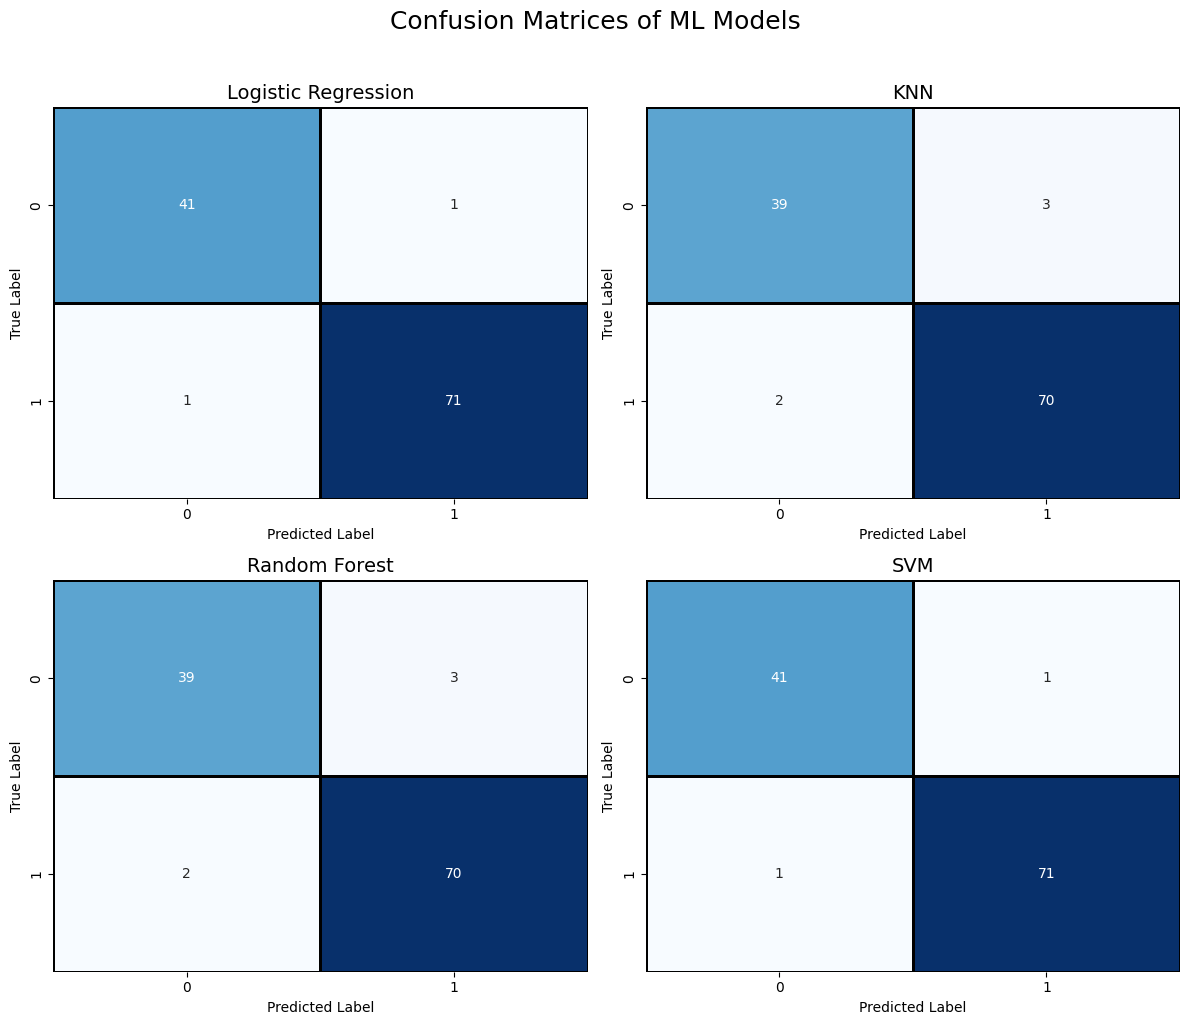

In [10]:
def plot_confusion_matrices_grid( models, X_train, X_test, y_train, y_test ):

    num_models = len(models)
    cols = 2
    rows = math.ceil(num_models / cols)

    fig, axes = plt.subplots( rows, cols, figsize=(12, 5 * rows) )

    # Flatten axes for easy looping
    axes = axes.flatten()

    for idx, (name, model) in enumerate(models.items()):

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)

        sns.heatmap( cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    linewidths=1, linecolor='black', ax=axes[idx]   )

        axes[idx].set_title( f"{name}", fontsize=14 )
        axes[idx].set_xlabel("Predicted Label")
        axes[idx].set_ylabel("True Label")

    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle( "Confusion Matrices of ML Models", fontsize=18, y=1.02 )
    plt.tight_layout()
    plt.show()


plot_confusion_matrices_grid( models, X_train, X_test, y_train, y_test )

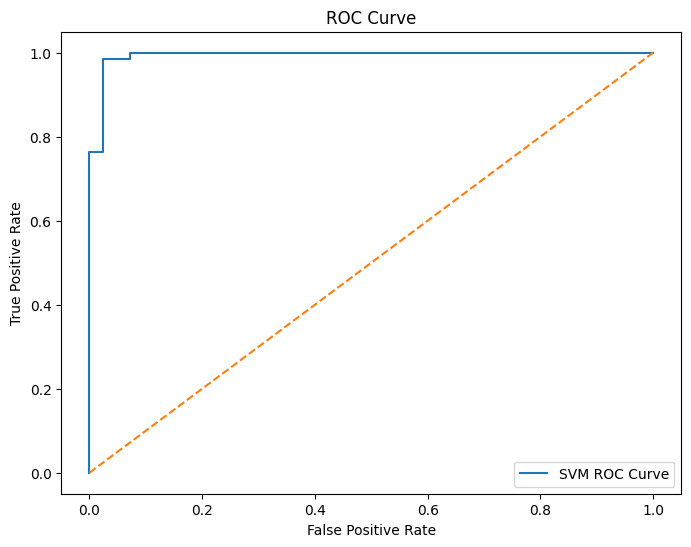

In [11]:
# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label="SVM ROC Curve")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [12]:
# Feature Importance ( Random Forest )

rf_model = models["Random Forest"]
rf_model.fit(X_train, y_train)

feature_importance = ( rf_model.named_steps["model"].feature_importances_ )

importance_df = pd.DataFrame({ "Feature": X.columns, "Importance": feature_importance })

importance_df = importance_df.sort_values( by="Importance", ascending=False )

print("\nTop 10 Important Features:\n")
print(importance_df.head(10))


Top 10 Important Features:

                 Feature  Importance
23            worst area    0.140016
27  worst concave points    0.129530
20          worst radius    0.097696
7    mean concave points    0.090885
22       worst perimeter    0.072226
2         mean perimeter    0.069574
0            mean radius    0.068676
6         mean concavity    0.057638
3              mean area    0.049172
26       worst concavity    0.034340


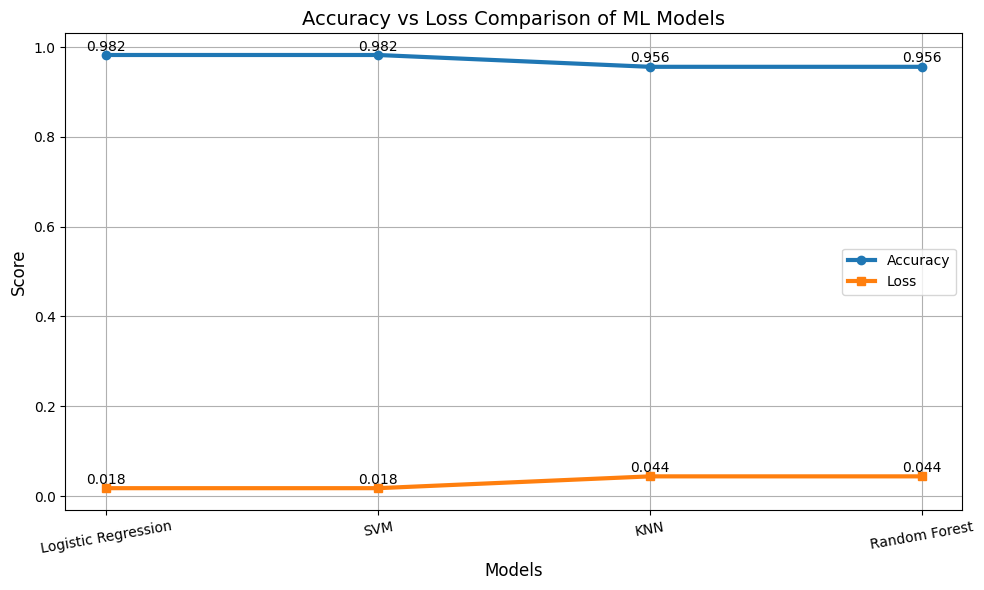

In [13]:
def plot_accuracy_vs_loss(model_results):

    # Convert to DataFrame
    results_df = pd.DataFrame({ "Model": list(model_results.keys()),
                            "Accuracy": list(model_results.values())    })

    results_df["Loss"] = 1 - results_df["Accuracy"]

    # Sort for better visualization
    results_df = results_df.sort_values( by="Accuracy", ascending=False )

    plt.figure(figsize=(10, 6))

    plt.plot( results_df["Model"], results_df["Accuracy"], marker='o',
              linewidth=3, label="Accuracy"  )

    plt.plot( results_df["Model"], results_df["Loss"], marker='s',
              linewidth=3, label="Loss" )

    plt.xlabel("Models", fontsize=12)
    plt.ylabel("Score", fontsize=12)

    plt.title( "Accuracy vs Loss Comparison of ML Models", fontsize=14 )

    plt.xticks(rotation=10)
    plt.grid(True)
    plt.legend()

    for i, row in results_df.iterrows():

        plt.text( row["Model"], row["Accuracy"] + 0.01, f'{row["Accuracy"]:.3f}', ha='center' )

        plt.text( row["Model"], row["Loss"] + 0.01, f'{row["Loss"]:.3f}', ha='center'  )

    plt.tight_layout()
    plt.show()

plot_accuracy_vs_loss(results)

In [14]:
# Save the model

import joblib

joblib.dump(best_svm, "breast_cancer_detection.pkl")

print("\nFinal optimized SVM model saved successfully!")


Final optimized SVM model saved successfully!
